# 12 Clipping

In this lesson we will learn how to to clip different geometries.

## About the data

We will use three datasets in this lesson. 

The first dataset is a [TIGER shapefile of the US states from the United States Census Bureau](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.2022.html#list-tab-790442341). Follow these steps to download shapefile with the United States' states:

You can check the [metadata for all the TIGER shapefiles here](https://www.census.gov/programs-surveys/geography/technical-documentation/complete-technical-documentation/tiger-geo-line.html). 

The second dataset we'll use is [Natural Earth's simple medium scale populated places dataset](https://www.naturalearthdata.com/downloads/50m-cultural-vectors/). We can obtain this dataset by downloading the shapefile (choose the one that says "simple (less columns)").

The third dataset we'll use is [Natural Earth's road dataset](https://www.naturalearthdata.com/downloads/10m-cultural-vectors/roads/). 
We can obtain this dataset by downloading the shapefile 

We will combine these datasets to create the following map of infrastructure in Alaska:

## Import data

Let's start by loading our libraries and then importing the datasets we will use.


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

from shapely.geometry import box  # To create polygon bounding box


pd.set_option("display.max.columns", None)

# -------------------------------------------------------
# Import and simplify states polygons
states = gpd.read_file(os.path.join('data', 
                                    'tl_2022_us_state', 
                                    'tl_2022_us_state.shp'))

# Import Natural Earth populated places points
places = gpd.read_file(os.path.join('data',
                                    'ne_50m_populated_places_simple',
                                    'ne_50m_populated_places_simple.shp')
                                    )

# Import roads
roads = gpd.read_file(os.path.join('data',
                                   'ne_10m_roads',
                                   'ne_10m_roads.shp')
                                   )

## Check-in
Use a for loop to iterate over the three geo-dataframes we imported and change their column names to lower caps.

In [2]:
for df in [states, places, roads]:
    df.columns = df.columns.str.lower()

## Prepare Alaska multipolygon

In [3]:
# Check CRS & head
print(states.crs)
states.head()

EPSG:4269


,region,division,statefp,statens,geoid,stusps,name,lsad,mtfcc,funcstat,aland,awater,intptlat,intptlon,geometry
0,3,5,54,01779805,54,WV,West Virginia,00,G4000,A,62266456923,489045863,+38.6472854,-080.6183274,"POLYGON ((-77.75438 39.33346, -77.75422 39.333..."
1,3,5,12,00294478,12,FL,Florida,00,G4000,A,138962819934,45971472526,+28.3989775,-082.5143005,"MULTIPOLYGON (((-83.10874 24.62949, -83.10711 ..."
2,2,3,17,01779784,17,IL,Illinois,00,G4000,A,143778515726,6216539665,+40.1028754,-089.1526108,"POLYGON ((-87.89243 38.28285, -87.89334 38.282..."
3,2,4,27,00662849,27,MN,Minnesota,00,G4000,A,206244837557,18937184315,+46.3159573,-094.1996043,"POLYGON ((-95.31989 48.99892, -95.31747 48.998..."
4,3,5,24,01714934,24,MD,Maryland,00,G4000,A,25151771744,6979295311,+38.9466584,-076.6744939,"POLYGON ((-75.75600 39.24607, -75.75579 39.243..."


<Axes: >

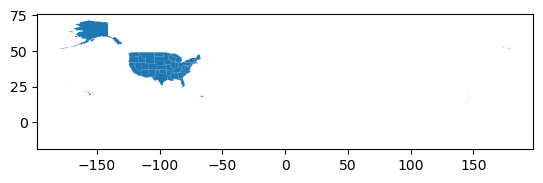

In [4]:
# Initial states plot
states.plot()

<Axes: >

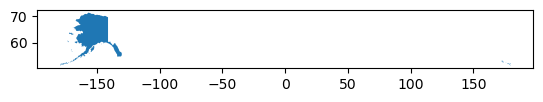

In [5]:
# Select only Alaska
alaska = states[states['name'] == "Alaska"]
alaska.plot()

In [6]:
# Reproject to CRS optimized for Alaska
alaska = alaska.to_crs('EPSG:3338')

# Inspect the new CRS
print('Is this CRS projected? ', alaska.crs.is_projected)
print(alaska.crs)

Is this CRS projected?  True
EPSG:3338


<Axes: >

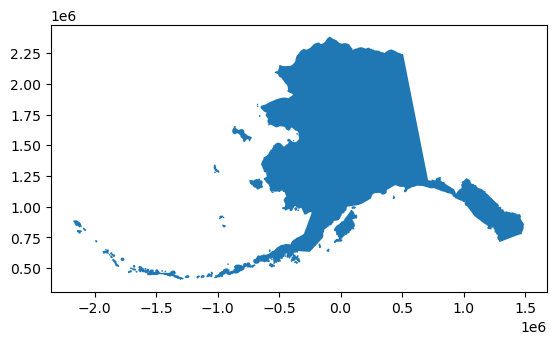

In [7]:
# Plot Alaska in new CRS
alaska.plot()

## Prepare populated places

EPSG:4326


<Axes: >

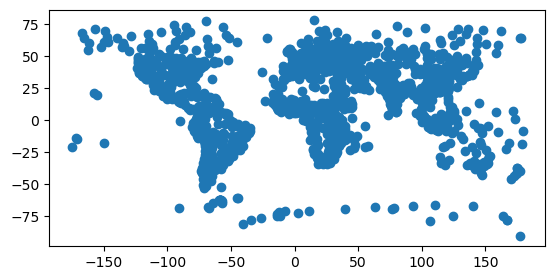

In [8]:
# Print CRS
print(places.crs)

# Initial plot
places.plot()

In [9]:
# Reproject to new crs and create assert check
places = places.to_crs('EPSG:3338')

assert alaska.crs == places.crs, f"CRS's do not match"

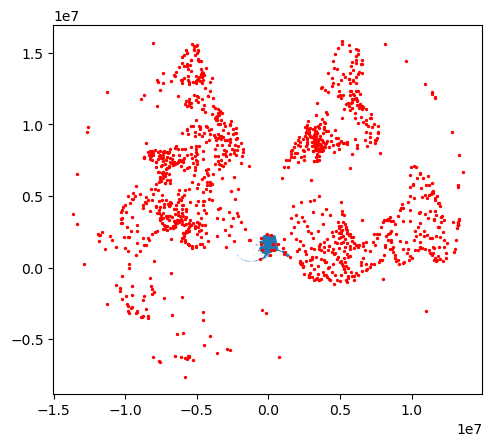

In [10]:
# Plot matched geodfs
fig, ax = plt.subplots()

alaska.plot(ax=ax)
places.plot(ax=ax, color='red', markersize=2)

plt.show()

## Clipping geo-data

`.clip()`

<Axes: >

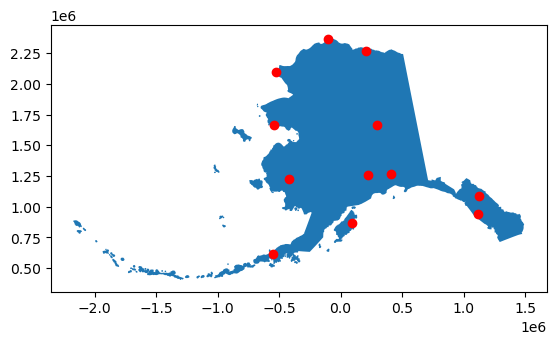

In [11]:
# Clip places to alaska gdf & map
ak_places = gpd.clip(places, alaska)

fig, ax = plt.subplots()

alaska.plot(ax=ax)
ak_places.plot(ax=ax, color='red')

## Prepare roads

In [12]:
# Handle crs
if roads.crs != places.crs:
    print(f"Old CRS: {roads.crs}\nConverting to roads data to: {places.crs}")
    roads = roads.to_crs('EPSG:3338')
else:
    print("CRS's match, continue as is.")

Old CRS: EPSG:4326
Converting to roads data to: EPSG:3338


In [13]:
# Filter to only US roads
us_roads = roads[roads['sov_a3'] == 'USA']

In [14]:
# Clip roads data
ak_roads = gpd.clip(us_roads, alaska)

<Axes: >

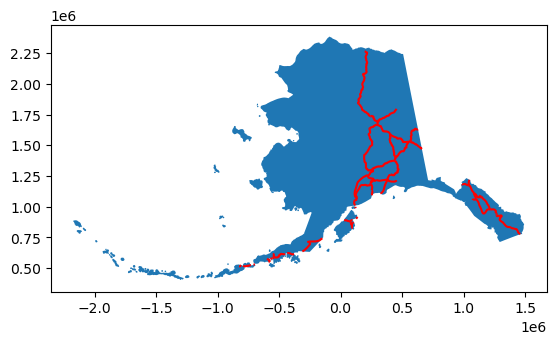

In [15]:
# Plot roads with alaska
fig, ax = plt.subplots()

alaska.plot(ax=ax)
ak_roads.plot(ax=ax, color='red')

## Clipping with a bounding box

`.box()`

- `*`: unpacking operator, in this 'unpacking' the array `alaska.total_bounds`

In [16]:
# Create box from alaska's total bounds
bbox = box(*alaska.total_bounds)
print(type(bbox))

<class 'shapely.geometry.polygon.Polygon'>


In [17]:
# Assign geospatial elements to box
ak_bbox = gpd.GeoDataFrame(geometry=[bbox], crs=alaska.crs)
print(type(ak_bbox))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [18]:
# Clip with bounding box
ak_complete_roads = gpd.clip(us_roads, ak_bbox)

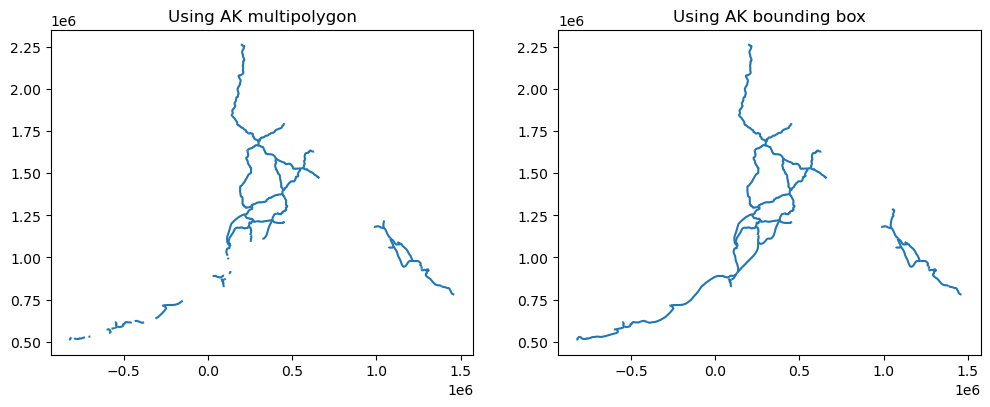

In [19]:
# Compare clipping methods
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,10))

ak_roads.plot(ax=ax1)
ax1.set_title("Using AK multipolygon")

ak_complete_roads.plot(ax=ax2)
ax2.set_title("Using AK bounding box")

plt.show()

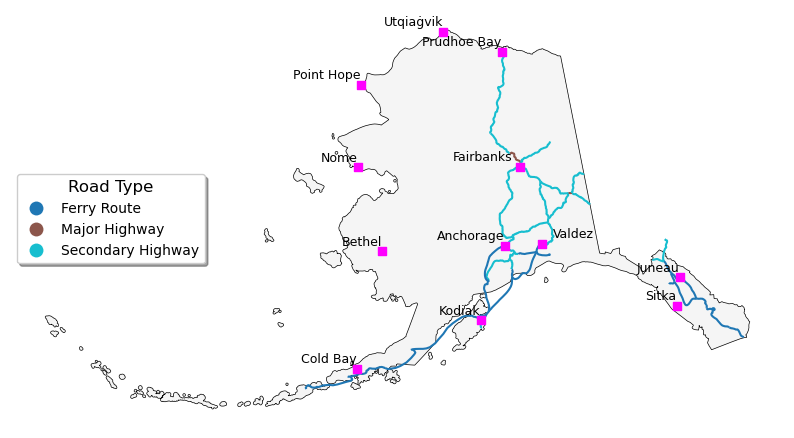

In [21]:
# Create final plot
fig, ax = plt.subplots(figsize=(10,10))

ax.axis('off')

alaska.plot(ax=ax, facecolor='whitesmoke', edgecolor='black', linewidth=0.5)

ak_complete_roads.plot(ax=ax, column='type', legend=True, zorder=1,
                       legend_kwds={'loc':'center left', 'title':'Road Type', 'title_fontsize':'large', 'shadow':True})

ak_places.plot(ax=ax, zorder=2, marker='s', color='fuchsia')

for x, y, name in zip(ak_places.geometry.x, ak_places.geometry.y, ak_places['name']):
    if name == 'Valdez':
        ax.text(x+60000, y+30000, name, fontsize=9) # Offset overlapping Valdez label
    elif name == 'Fairbanks':
        ax.text(x-350000, y+30000, name, fontsize=9) # Offset Fairbanks label
    else: 
        ax.text(x-3000, y+30000, name, fontsize=9, ha='right')